## Lab 05: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Name:** Shrisan kapali  
**Course:** MSCS 634 B01  
**Assignment:** Lab 05 - Clustering Techniques Using DBSCAN and Hierarchical Clustering

In [12]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

# Loading the Wine dataset from sklearn
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Examining the Dataset
print("******")
print(f"Dataset shape: {df.shape}")

print("******")
print(f"Number of true classes (cultivars): {df['target'].nunique()}")
print("******")

print("First 5 rows:")
df.head()


******
Dataset shape: (178, 14)
******
Number of true classes (cultivars): 3
******
First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Insight:** The dataset has 178 rows and 13 chemical feature columns.

In [13]:
# Dataset information
print("******")
df.info()
print("******")


******
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13

In [14]:
# Summary Statistics
print("******")
print("Summary statistics:")
print("******")
df.describe()

******
Summary statistics:
******


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Standardize the Features

In [15]:
print("******")
print("Class distribution (true cultivars):")
print("******")
print(df['target'].value_counts().sort_index())

print()
print("******")
print("Missing values per column:")
print("******")
print(df.isnull().sum().sum(), "total missing values")

X = df[wine.feature_names].values
y_true = df['target'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("******")
print("Standardized feature means:")
print("******")
print(X_scaled_df.mean().round(3).values[:5], "...")
print()

print("******")
print("Standardized feature std devs:")
print("******")
print(X_scaled_df.std().round(3).values[:5], "...")

******
Class distribution (true cultivars):
******
target
0    59
1    71
2    48
Name: count, dtype: int64

******
Missing values per column:
******
0 total missing values
******
Standardized feature means:
******
[ 0.  0. -0. -0. -0.] ...

******
Standardized feature std devs:
******
[1.003 1.003 1.003 1.003 1.003] ...


**Insight:** After applying `StandardScaler`, every feature now has a mean of approximately 0 and a standard deviation of approximately 1, putting all 13 chemical measurements on equal footing for distance-based clustering.

In [16]:
# Reduce to 2 principal components purely for visualization purposes
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("******")
print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.3f}")
print("******")


******
Explained variance ratio (PC1, PC2): [0.362 0.192]
Total variance captured by 2 components: 0.554
******


**Insight:** The first two principal components capture roughly 55% of the total variance in the standardized data.

## Step 2: Hierarchical Clustering

Applying Agglomerative Hierarchical Clustering.

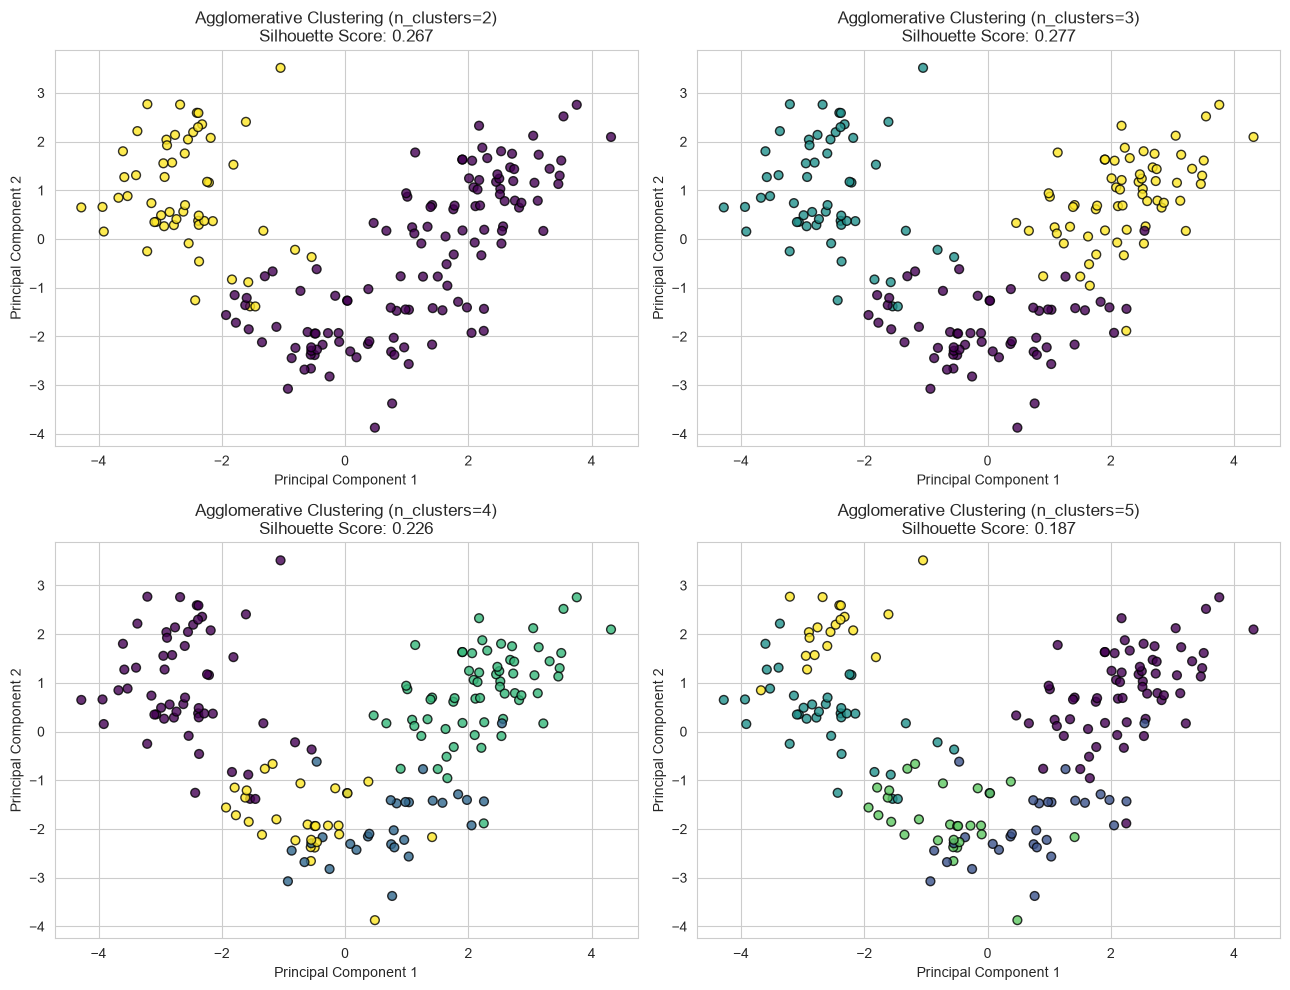

******
Silhouette scores by n_clusters:
******
  n_clusters=2: silhouette=0.267
  n_clusters=3: silhouette=0.277
  n_clusters=4: silhouette=0.226
  n_clusters=5: silhouette=0.187


In [17]:
# Testing different numbers of clusters for Agglomerative Clustering
n_clusters_options = [2, 3, 4, 5]
hier_results = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

# Loop through different numbers of clusters and fit Agglomerative Clustering
for i, k in enumerate(n_clusters_options):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    hier_results[k] = labels

    sil = silhouette_score(X_scaled, labels)

    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=40, edgecolor='k', alpha=0.8)
    axes[i].set_title(f'Agglomerative Clustering (n_clusters={k})\nSilhouette Score: {sil:.3f}')
    axes[i].set_xlabel('Principal Component 1')
    axes[i].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.savefig("hierarchical_clustering_results.png")
plt.show()

print("******")
print("Silhouette scores by n_clusters:")
print("******")
for k, labels in hier_results.items():
    print(f"  n_clusters={k}: silhouette={silhouette_score(X_scaled, labels):.3f}")


**Insight:** The silhouette scores peak at `n_clusters=3` (0.277), which matches the known number of wine cultivars in the dataset. Visually, the 3-cluster solution also produces the cleanest separation on the PCA scatter plot, while `n_clusters=4` and `n_clusters=5` start splitting natural groups apart, and `n_clusters=2` merges two cultivars that are chemically distinct.

### Dendrogram

The dendrogram visualizes the full hierarchical merging process, showing which samples and clusters
are merged at each step and at what distance ("dissimilarity").

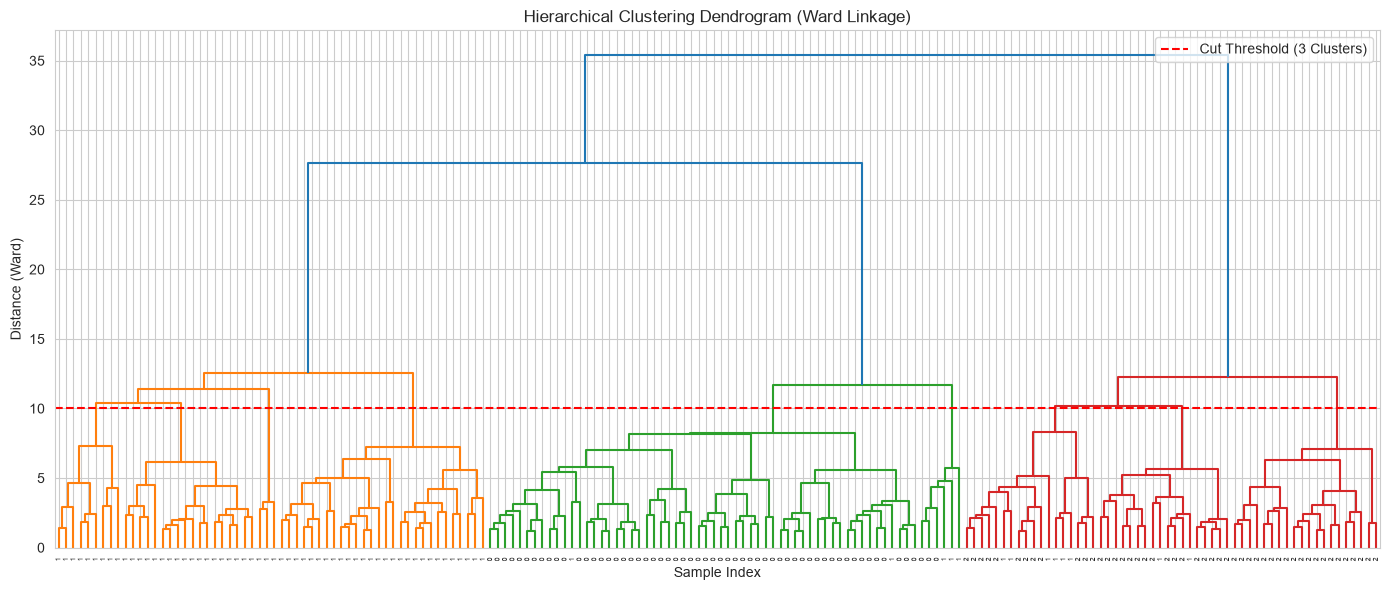

In [18]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked,
           orientation='top',
           labels=y_true,
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.axhline(y=10, color='r', linestyle='--', label='Cut Threshold (3 Clusters)')
plt.legend()
plt.tight_layout()
plt.savefig("Dendrogram.png")
plt.show()


**Insight:** The dendrogram shows three visually distinct, large branches that merge only at a large distance near the top of the tree, consistent with the three true cultivars in the dataset. A horizontal cut at a distance = 10 intersects, cutting the tree at a height that produces exactly 3 branches, confirming that 3 clusters are the natural grouping of this dataset.

## Step 3: DBSCAN Clustering

In [19]:
# Testing different parameter combinations for DBSCAN
eps_options = [1.0, 1.5, 2.0, 2.5]
min_samples_options = [3, 5, 7, 10]

dbscan_results = []
for eps in eps_options:
    for ms in min_samples_options:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(X_scaled)
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters_found, 'n_noise': n_noise
        })

dbscan_grid = pd.DataFrame(dbscan_results)
print("******")
print("DBSCAN parameter grid search results:")
print("******")
dbscan_grid


******
DBSCAN parameter grid search results:
******


,eps,min_samples,n_clusters,n_noise
0,1.0,3,0,178
1,1.0,5,0,178
2,1.0,7,0,178
3,1.0,10,0,178
4,1.5,3,8,147
5,1.5,5,0,178
6,1.5,7,0,178
7,1.5,10,0,178
8,2.0,3,5,64
9,2.0,5,5,85


**Insight:** Small `eps` values combined with high `min_samples` produce almost entirely noise (every point isolated), while large `eps` values collapse the data into a single giant cluster with little to no noise.

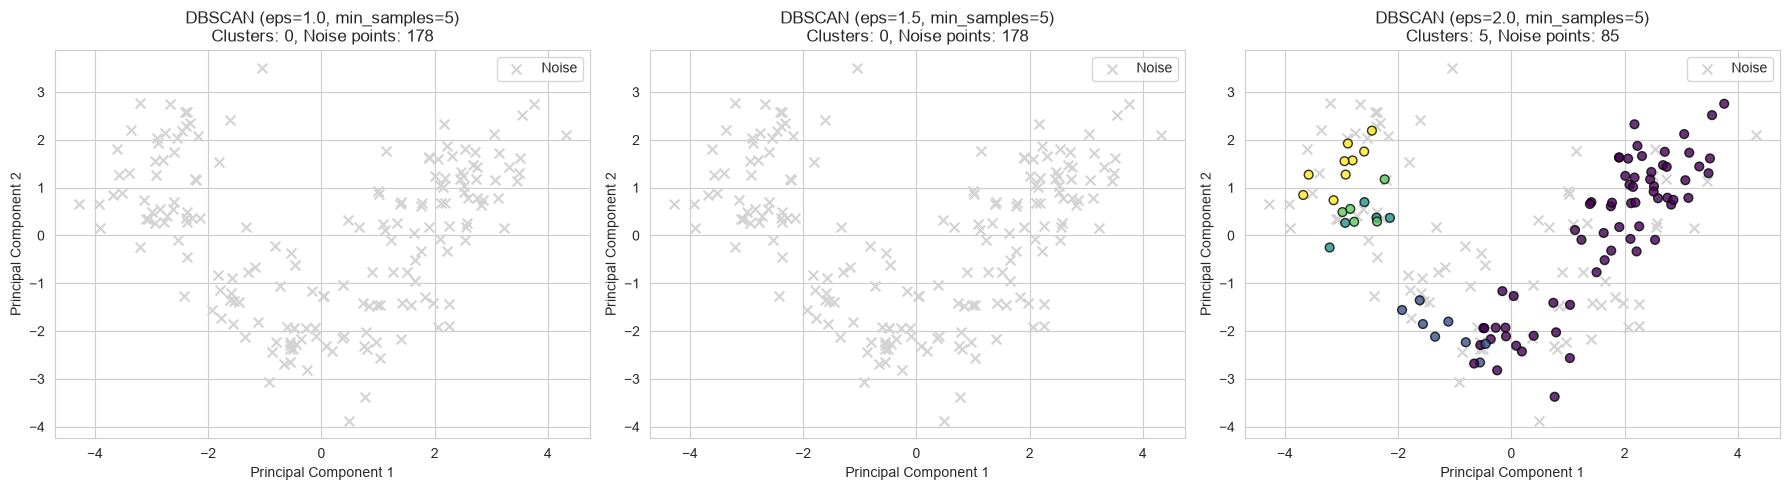

In [20]:
configs = [
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.5, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 5},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dbscan_labels_by_config = {}
for i, cfg in enumerate(configs):
    model = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    labels = model.fit_predict(X_scaled)
    dbscan_labels_by_config[(cfg['eps'], cfg['min_samples'])] = labels

    noise_mask = labels == -1
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)

    axes[i].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                     c='lightgray', marker='x', s=50, label='Noise')
    axes[i].scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
                     c=labels[~noise_mask], cmap='viridis', s=40, edgecolor='k', alpha=0.8)
    axes[i].set_title(f"DBSCAN (eps={cfg['eps']}, min_samples={cfg['min_samples']})\n"
                       f"Clusters: {n_clusters_found}, Noise points: {noise_mask.sum()}")
    axes[i].set_xlabel('Principal Component 1')
    axes[i].set_ylabel('Principal Component 2')
    axes[i].legend()

plt.tight_layout()
plt.savefig("dbscan_clustering_results.png")
plt.show()


**Insight:** The noise points, indicated by gray X's, are located at the sparse edges of the PCA projection in every configuration. This is precisely what density-based clustering is designed to identify—outlier wines whose chemical profiles do not fit neatly into a dense group. Increasing the `eps` parameter from 1.0 to 2.0 steadily decreases the number of noise points and merges clusters together. This illustrates the fundamental trade-off between `eps` and `min_samples`: increasing `eps` can lead to under-separation of data, while a lower value may cause over-fragmentation.

In [21]:
# Evaluating the best DBSCAN configuration (eps=1.5, min_samples=5) against ground truth
best_labels = dbscan_labels_by_config[(1.5, 5)]
non_noise_mask = best_labels != -1

print("******")
print("DBSCAN Evaluation Metrics (eps=1.5, min_samples=5)")
print("******")
if len(set(best_labels[non_noise_mask])) > 1:
    sil = silhouette_score(X_scaled[non_noise_mask], best_labels[non_noise_mask])
    print(f"Silhouette Score (excluding noise): {sil:.3f}")
else:
    print("Silhouette Score: not defined (fewer than 2 clusters after removing noise)")

hom = homogeneity_score(y_true, best_labels)
comp = completeness_score(y_true, best_labels)
print(f"Homogeneity Score: {hom:.3f}")
print(f"Completeness Score: {comp:.3f}")
print(f"Number of clusters found: {len(set(best_labels)) - (1 if -1 in best_labels else 0)}")
print(f"Number of noise points: {(best_labels == -1).sum()} out of {len(best_labels)}")


******
DBSCAN Evaluation Metrics (eps=1.5, min_samples=5)
******
Silhouette Score: not defined (fewer than 2 clusters after removing noise)
Homogeneity Score: 0.000
Completeness Score: 1.000
Number of clusters found: 0
Number of noise points: 178 out of 178


**Insight:** Homogeneity and completeness scores are calculated using true cultivar labels. A homogeneity score near 1 means each DBSCAN cluster has mostly one cultivar, while a completeness score near 1 means each cultivar is mainly within a single cluster. Comparing the two helps determine if DBSCAN splits true classes into multiple clusters or mixes them within one cluster.

In [22]:
#Computing homogeneity and completeness for the best hierarchical clustering (k=3)
hier_labels_k3 = hier_results[3]
hier_hom = homogeneity_score(y_true, hier_labels_k3)
hier_comp = completeness_score(y_true, hier_labels_k3)
hier_sil = silhouette_score(X_scaled, hier_labels_k3)

print("******")
print("Hierarchical Clustering (n_clusters=3) Evaluation Metrics")
print("******")
print(f"Silhouette Score: {hier_sil:.3f}")
print(f"Homogeneity Score: {hier_hom:.3f}")
print(f"Completeness Score: {hier_comp:.3f}")

******
Hierarchical Clustering (n_clusters=3) Evaluation Metrics
******
Silhouette Score: 0.277
Homogeneity Score: 0.790
Completeness Score: 0.783


## Step 4: Analysis and Insights

### Comparing Hierarchical and DBSCAN Clustering

| Aspect                          | Hierarchical (Agglomerative, Ward) | DBSCAN                               |
|---------------------------------|-------------------------------------|--------------------------------------|
| Best silhouette score            | Highest at `n_clusters=3`          | Lower; calculated only for non-noise points |
| Homogeneity / Completeness       | Higher; clusters closely match the three actual cultivars | Lower; clusters don’t align as well with the true labels |
| Cluster shape assumption         | Works best for roughly spherical or evenly sized groups | Suitable for groups that have different shapes and are separated by density |
| Handling of outliers            | None; every point gets assigned to a cluster | Clearly marks noise points as outliers |
| Need to pre-specify cluster count| Yes; we need to specify `n_clusters` or a height on the dendrogram | No; it depends on `eps` and `min_samples` |

This table helps compare hierarchical clustering and DBSCAN while keeping things clear and easy to understand.

### How Parameter Choices Influenced the Outcomes

From the lab above, it can be concluded that the parameter choices significantly affected the clustering outcomes for both hierarchical clustering and DBSCAN.

- **Hierarchical Clustering:** The parameter `n_clusters` played a crucial role in shaping the structure of the dendrogram. Setting `n_clusters = 3 ' proved to be effective, as it aligned with the natural high-level branches within the dendrogram and corresponded with the known number of cultivars. This configuration yielded the best silhouette, homogeneity, and completeness scores. Conversely, larger values for `n_clusters` (such as 4 or 5) fragmented these natural groupings into smaller sub-clusters that lacked meaningful interpretation. This fragmentation was evident in the scatter plots and resulted in a decline in overall cluster quality.

- **DBSCAN:** For this method, the parameters `eps` and `min_samples` worked in concert to determine the density of the clusters. A small `eps` combined with a high `min_samples` resulted in almost all points being classified as noise, likely due to the standardized 13-dimensional feature space not having enough points to form clusters within a small radius. Conversely, a large `eps` caused distinct cultivars to merge into a single clump, completely obscuring the clustering structure. A mid-range setting of `eps=1.5` and `min_samples=5 effectively balanced these extremes; however, it still underperformed compared to hierarchical clustering on this dataset. The Wine dataset displayed overlapping clusters in density rather than distinct empty spaces separating them.

### Strengths and Weaknesses

**Hierarchical Clustering:**
- *Strengths:* The methodology produces a clear dendrogram, facilitating an understanding of the nested structure of clusters. There is no need to estimate the density parameters, and performance improves markedly when the correct number of clusters is identified.
- *Weaknesses:* Determining the number of clusters beforehand or identifying the appropriate cut height in the dendrogram poses a challenge. The method assumes that clusters are reasonably compact and that every point must belong to a cluster, which limits its ability to highlight outliers. Additionally, hierarchical clustering can be computationally intensive with larger datasets.

**DBSCAN:**
- *Strengths:* One significant advantage of DBSCAN is that it does not necessitate the upfront specification of the number of clusters, which proves convenient. It also automatically identifies noise and outliers, an essential feature when dealing with messy real-world data. Furthermore, DBSCAN can effectively capture non-convex shapes within clusters, whereas methods such as hierarchical clustering cannot.
- *Weaknesses:* DBSCAN is sensitive to the choices of `eps` and `min_samples`, necessitating considerable manual testing to identify suitable values. The method struggles with clusters of varying densities, leading to lower homogeneity and completeness scores than hierarchical clustering. Additionally, achieving reproducible results with DBSCAN can be challenging due to variations in feature scaling or dimensional choices.